# Fingerprint Recognition Model

**Dataset**: [SOCOFing – Sokoto Coventry Fingerprint Dataset](https://www.kaggle.com/datasets/ruizgara/socofing)  
**Task**: Fingerprint subject identification (600-class classification)  
**Architecture**: CNN with BatchNormalization & Dropout

---
## Dataset Overview
- 6,000 fingerprint images from **600 subjects** (10 fingers each)
- Additional altered versions: Easy / Medium / Hard
- Filename format: `{subject_id}__{gender}_{hand}_{finger}_finger.BMP`
- We use only the **Real** (unaltered) images for training

## Step 0: Install Dependencies

In [1]:
# All packages already installed:
# kaggle, opencv-python, tensorflow, scikit-learn, matplotlib, seaborn
# Uncomment if running on a fresh environment:
# !pip install kaggle opencv-python tensorflow scikit-learn matplotlib seaborn

## Step 1: Download Dataset from Kaggle

> **Kaggle auth** is pre-configured via `~/.kaggle/access_token`.  
> The dataset is ~838 MB and will be downloaded on first run only.

In [2]:
import os

DATASET_DIR = './socofing'
REAL_DIR    = os.path.join(DATASET_DIR, 'SOCOFing', 'Real')

if not os.path.exists(REAL_DIR):
    os.makedirs(DATASET_DIR, exist_ok=True)
    # Token stored in ~/.kaggle/access_token — kaggle CLI picks it up automatically
    ret = os.system(f'kaggle datasets download -d ruizgara/socofing -p {DATASET_DIR} --unzip')
    if ret != 0:
        raise RuntimeError('Download failed. Check ~/.kaggle/access_token exists.')
    print('Dataset downloaded and extracted.')
else:
    print('Dataset already exists, skipping download.')

print('Files in Real folder:', len(os.listdir(REAL_DIR)))

Dataset already exists, skipping download.
Files in Real folder: 6000


## Step 2: Load & Preprocess Fingerprint Images

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

IMG_SIZE    = 96    # resize all fingerprints to 96×96
NUM_CLASSES = 600   # 600 unique subjects

images = []
labels = []

for filename in sorted(os.listdir(REAL_DIR)):
    if not filename.lower().endswith('.bmp'):
        continue

    # Extract subject ID from filename: "1__M_Left_index_finger.BMP" → label 0
    subject_id = int(filename.split('__')[0]) - 1   # 0-indexed

    img_path = os.path.join(REAL_DIR, filename)
    img      = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img      = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    images.append(img)
    labels.append(subject_id)

# Convert to numpy arrays
X = np.array(images, dtype='float32') / 255.0      # normalise to [0, 1]
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)            # add channel dim
y = to_categorical(np.array(labels), NUM_CLASSES)   # one-hot encode

print(f'Images shape : {X.shape}')   # (6000, 96, 96, 1)
print(f'Labels shape : {y.shape}')   # (6000, 600)

Images shape : (6000, 96, 96, 1)
Labels shape : (6000, 600)


## Step 3: Visualise Sample Fingerprints

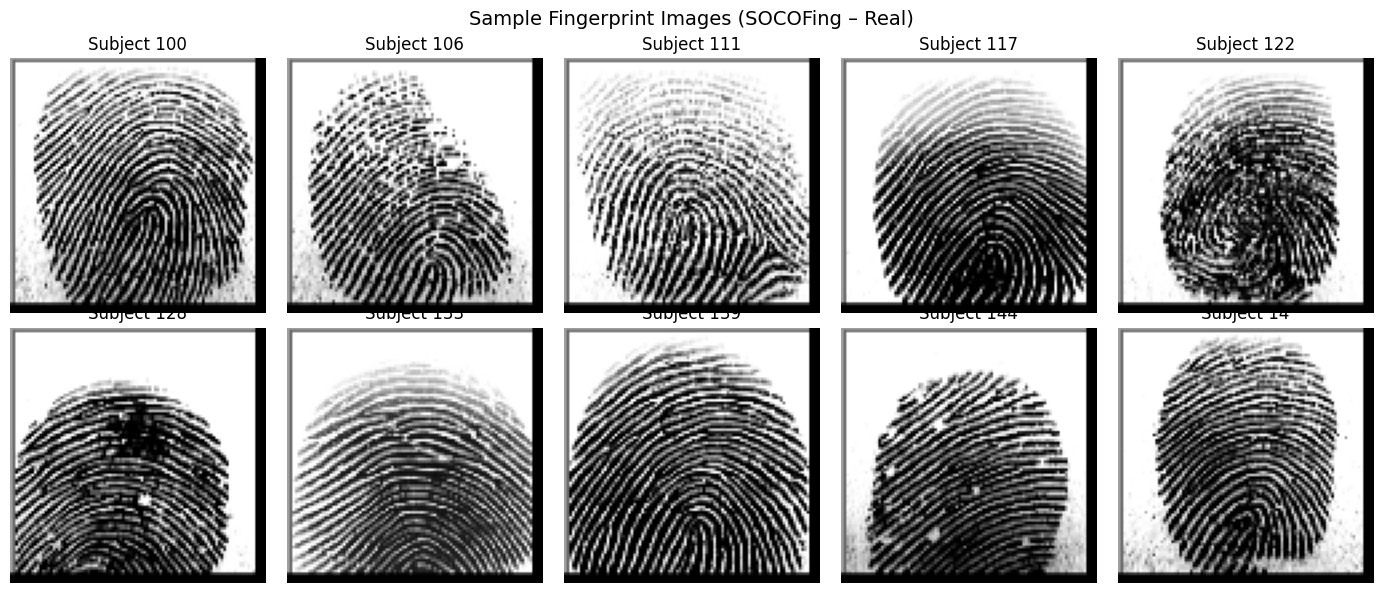

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Sample Fingerprint Images (SOCOFing – Real)', fontsize=14)

for i, ax in enumerate(axes.flat):
    ax.imshow(X[i * 60].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    ax.set_title(f'Subject {np.argmax(y[i * 60]) + 1}')
    ax.axis('off')

plt.tight_layout()
plt.show()

## Step 4: Train / Validation / Test Split

In [5]:
# 70% train | 15% val | 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f'Train : {X_train.shape[0]} images')
print(f'Val   : {X_val.shape[0]} images')
print(f'Test  : {X_test.shape[0]} images')

Train : 4200 images
Val   : 900 images
Test  : 900 images


## Step 5: Data Augmentation

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,       # slight rotations (fingerprint can be placed at an angle)
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    horizontal_flip=False,   # fingerprints are NOT horizontally symmetric
    fill_mode='nearest'
)

datagen.fit(X_train)
print('Data augmentation configured.')

Data augmentation configured.


## Step 6: Build the CNN Model

Architecture:
```
Input (96×96×1)
  ↓  Conv Block 1 – 32 filters  → MaxPool  96→48
  ↓  Conv Block 2 – 64 filters  → MaxPool  48→24
  ↓  Conv Block 3 – 128 filters → MaxPool  24→12
  ↓  Conv Block 4 – 256 filters (no pool)  12→12
  ↓  Conv Block 5 – 256 filters → MaxPool  12→6
  ↓  GlobalAveragePooling2D
  ↓  Dense(512) + BN + Dropout(0.5)
  ↓  Dense(600, softmax)
```

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

def conv_block(x, filters, kernel_size=3, pool=True):
    """Conv2D → BatchNorm → ReLU → (optional MaxPool)"""
    x = layers.Conv2D(filters, kernel_size, padding='same',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    if pool:
        x = layers.MaxPooling2D((2, 2))(x)
    return x

# ── Model definition ───────────────────────────────────────────────────────
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

#First block, 32 filters, reduces image size from 96×96 to 48×48 (with pooling).
x = conv_block(inputs, 32)           # 96→48

# Second block, 64 filters, further reduces size to 24×24.
x = conv_block(x, 64)                # 48→24

# 128 filters, reduces to 12×12.
x = conv_block(x, 128)               # 24→12

# 256 filters, keeps size at 12×12 to preserve spatial information.
x = conv_block(x, 256, pool=False)   # 12→12  (keep spatial info)

# Final block, 256 filters, reduces to 6×6.
x = conv_block(x, 256)               # 12→6

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(512, kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.5)(x) #to prevent overfitting

outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs, name='FingerprintCNN')
model.summary()

Model: "FingerprintCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 96, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,58

 Total params: 1,422,296 (5.43 MB)

 Trainable params: 1,419,800 (5.42 MB)

 Non-trainable params: 2,496 (9.75 KB)

## Step 7: Compile the Model

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_acc')
    ]
)

print('Model compiled.')

Model compiled.


## Step 8: Callbacks

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1
    ),
    ModelCheckpoint(
        'best_fingerprint_model.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1
    ),
]

print('Callbacks ready.')

Callbacks ready.


## Step 9: Train the Model

In [10]:
BATCH_SIZE = 32
EPOCHS     = 50

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.0018 - loss: 7.0368 - top5_acc: 0.0092
Epoch 1: val_accuracy improved from None to 0.00222, saving model to best_fingerprint_model.keras

Epoch 1: finished saving model to best_fingerprint_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 104ms/step - accuracy: 0.0029 - loss: 6.9370 - top5_acc: 0.0142 - val_accuracy: 0.0022 - val_loss: 15.1918 - val_top5_acc: 0.0078 - learning_rate: 0.0010
Epoch 2/50
  1/131 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - accuracy: 0.0000e+00 - loss: 6.6197 - top5_acc: 0.0000e+00

/Users/damirdarasu/workspace/workbooks/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.00222
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0000e+00 - loss: 6.6197 - top5_acc: 0.0000e+00 - val_accuracy: 0.0022 - val_loss: 15.4261 - val_top5_acc: 0.0078 - learning_rate: 0.0010
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.0097 - loss: 6.1417 - top5_acc: 0.0437
Epoch 3: val_accuracy did not improve from 0.00222
131/131 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - accuracy: 0.0115 - loss: 6.1340 - top5_acc: 0.0461 - val_accuracy: 0.0011 - val_loss: 22.5935 - val_top5_acc: 0.0078 - learning_rate: 0.0010
Epoch 4/50
  1/131 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - accuracy: 0.0000e+00 - loss: 6.1357 - top5_acc: 0.0000e+00
Epoch 4: val_accuracy did not improve from 0.00222
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0000e+00 - loss: 6.1357 - top5_acc: 0.0000e+00 - val_accuracy: 0.0011 - val_loss: 22.5275 - val_top5_acc: 0.0078 - learning_rate: 0.0010
Epoch 5/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step -

## Step 10: Plot Training Curves

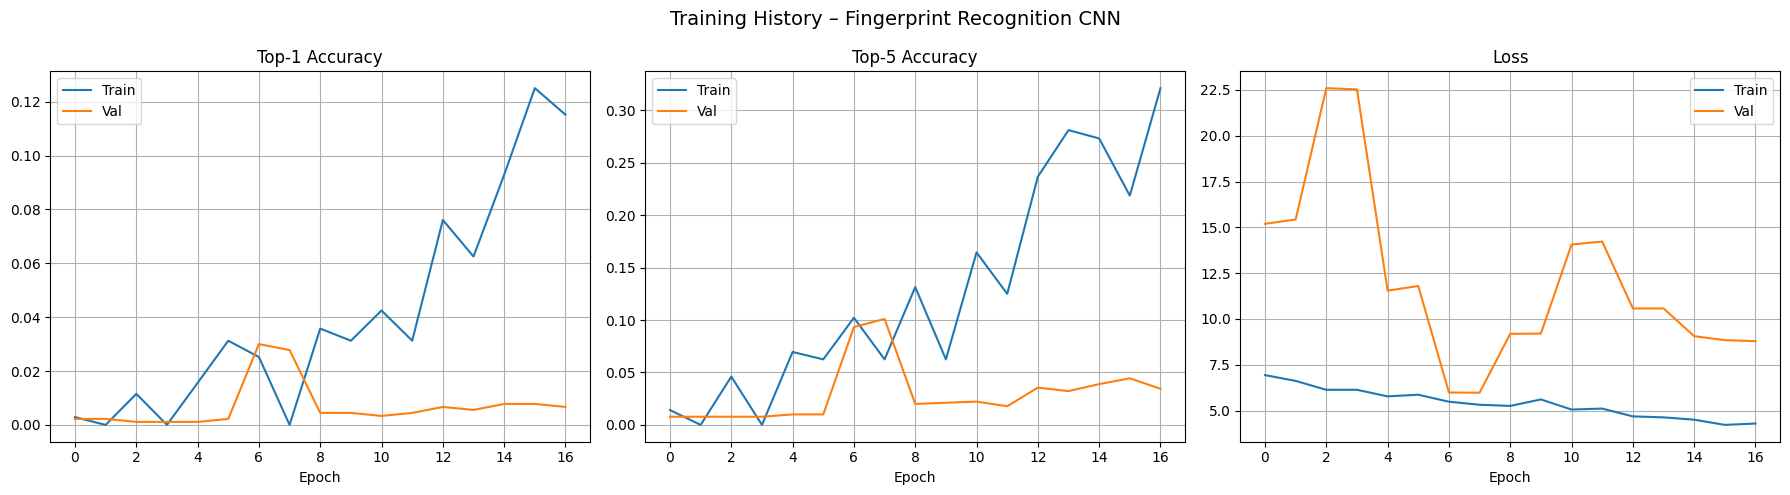

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Top-1 Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['top5_acc'],     label='Train')
axes[1].plot(history.history['val_top5_acc'], label='Val')
axes[1].set_title('Top-5 Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(history.history['loss'],     label='Train')
axes[2].plot(history.history['val_loss'], label='Val')
axes[2].set_title('Loss')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True)

plt.suptitle('Training History – Fingerprint Recognition CNN', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## Step 11: Evaluate on Test Set

In [12]:
test_loss, test_acc, test_top5 = model.evaluate(X_test, y_test, verbose=0)

print('=' * 40)
print(f'Test Loss      : {test_loss:.4f}')
print(f'Test Accuracy  : {test_acc * 100:.2f}%')
print(f'Test Top-5 Acc : {test_top5 * 100:.2f}%')
print('=' * 40)

Test Loss      : 5.9776
Test Accuracy  : 3.11%
Test Top-5 Acc : 9.11%


## Step 12: Confusion Matrix (Top 10 Subjects)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


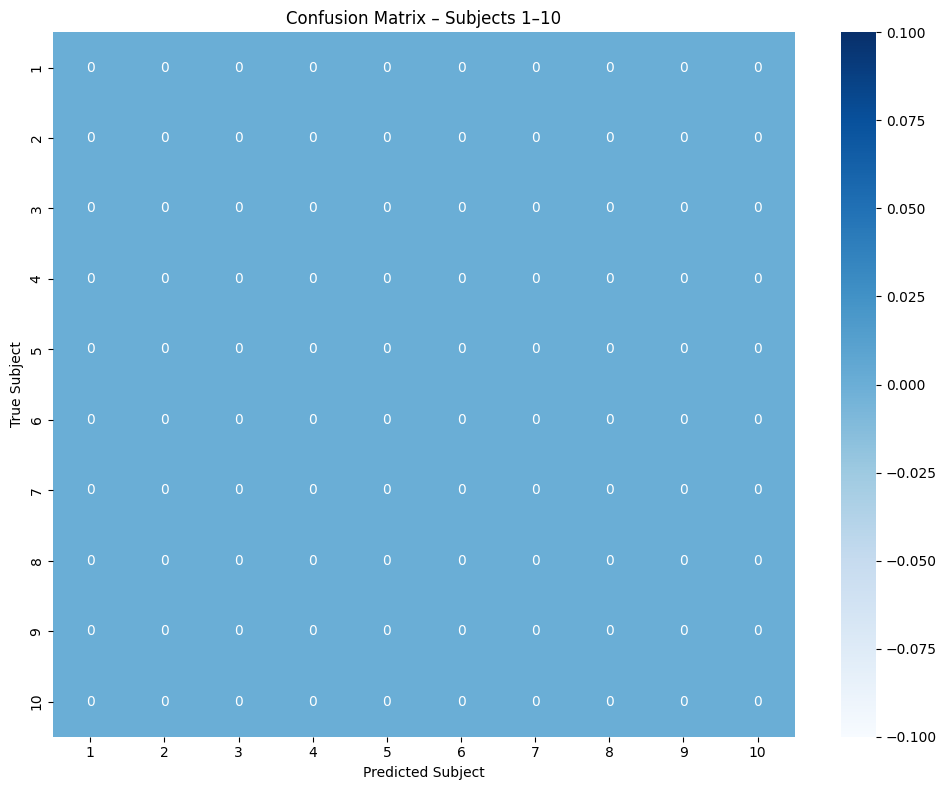


Classification Report (subjects 1–10):
              precision    recall  f1-score   support

   Subject 1       0.00      0.00      0.00       1.0
   Subject 2       0.00      0.00      0.00       1.0
   Subject 3       0.00      0.00      0.00       2.0
   Subject 4       0.00      0.00      0.00       1.0
   Subject 5       0.00      0.00      0.00       1.0
   Subject 6       0.00      0.00      0.00       2.0
   Subject 7       0.00      0.00      0.00       1.0
   Subject 8       0.00      0.00      0.00       1.0
   Subject 9       0.00      0.00      0.00       1.0
  Subject 10       0.00      0.00      0.00       2.0

   micro avg       0.00      0.00      0.00      13.0
   macro avg       0.00      0.00      0.00      13.0
weighted avg       0.00      0.00      0.00      13.0



In [13]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_pred_prob = model.predict(X_test)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = np.argmax(y_test, axis=1)

# Filter true labels for subjects 1–10 (0-indexed: 0–9)
mask   = y_true < 10
labels = list(range(10))   # restrict both CM and report to these classes

cm = confusion_matrix(y_true[mask], y_pred[mask], labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(1, 11), yticklabels=range(1, 11))
plt.xlabel('Predicted Subject')
plt.ylabel('True Subject')
plt.title('Confusion Matrix – Subjects 1–10')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print('\nClassification Report (subjects 1–10):')
print(classification_report(
    y_true[mask], y_pred[mask],
    labels=labels,
    target_names=[f'Subject {i}' for i in range(1, 11)],
    zero_division=0
))

## Step 13: Visualise Predictions

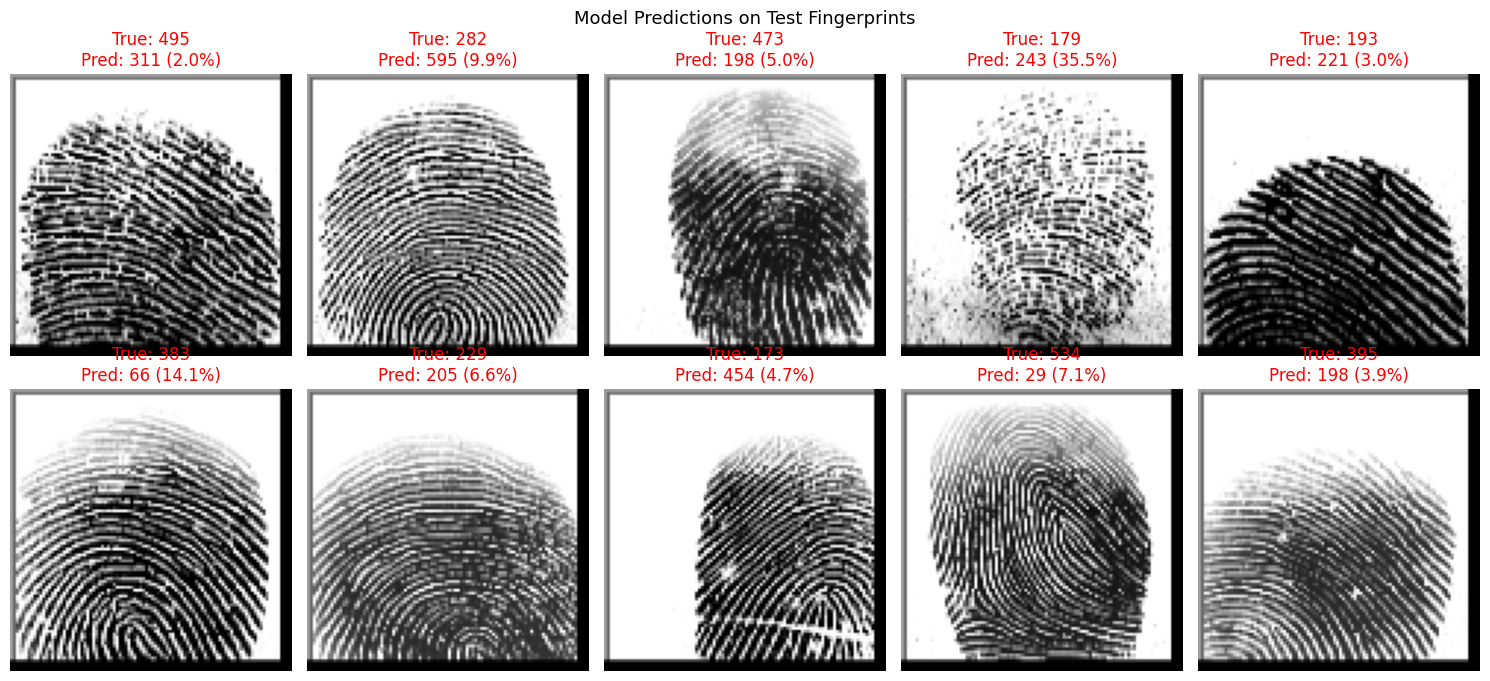

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle('Model Predictions on Test Fingerprints', fontsize=13)

for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    true_label = y_true[i] + 1
    pred_label = y_pred[i] + 1
    conf       = y_pred_prob[i, y_pred[i]] * 100
    color      = 'green' if true_label == pred_label else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label} ({conf:.1f}%)', color=color)
    ax.axis('off')

plt.tight_layout()
plt.savefig('predictions.png', dpi=150)
plt.show()

In [15]:
# Export Keras model to file
from tensorflow import keras
# Assume your model variable is named 'model' and is already trained
model.save('fingerprint_recognition_model.keras')
print('Model saved as fingerprint_recognition_model.keras')

Model saved as fingerprint_recognition_model.keras
